# Bank Customer Churn: EDA and Modeling

The data set used for this analysis and modeling exercise was obtained from Kaggle and comprises customer details for Bank ABC. The overall objective was to predict customer churn for the bank.

### Importing libraries, data set, and assessing variables & data quality

In [1]:
#Import the required EDA, visualisation, and modeling packages
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import pointbiserialr
import itertools
import seaborn as sns
import matplotlib.pylab as plt
from matplotlib import pyplot
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (classification_report, confusion_matrix, recall_score,
                              accuracy_score, precision_score, roc_auc_score,
                              precision_recall_curve)
from sklearn.inspection import PartialDependenceDisplay
from sklearn import tree
from statsmodels.stats.multitest import multipletests

In [115]:
#Import the unmodified Customer Churn data set
df = pd.read_csv('customer churn.csv')

In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [119]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


A quick examination of the min, mean, and max values does not indicate any suspicious outliers for most of the fields. The $11.58 minimum value for estimated_salary is a bit suspicious and will be examined in more detail later.

In [122]:
df.isnull().sum()
#There are no null values for any fields

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [124]:
#Check for duplicate values
df.duplicated().sum()
#No duplicate rows are detected

0

### Exploratory Data Analysis

#### Examining the spread of numerical variables

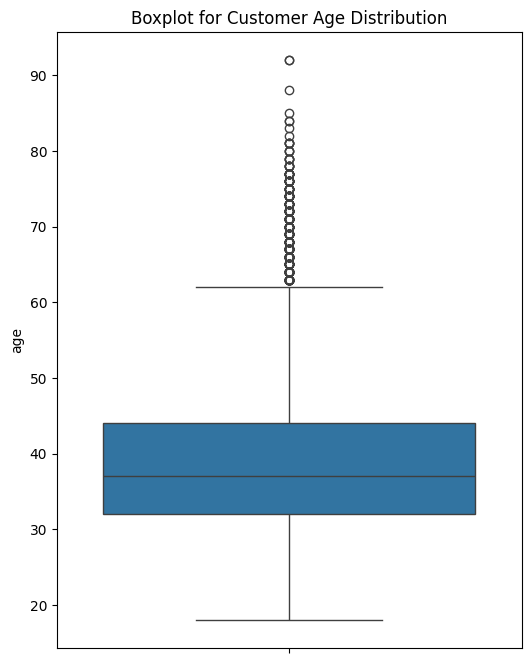

In [128]:
#Spread of Customer Age
plt.figure(figsize=(6, 8))
sns.boxplot(data=df['age'], orient="v")
plt.title("Boxplot for Customer Age Distribution")
plt.xticks(rotation=45)
plt.show()

The inner range for age distribution is between late teens and early 60s. Customers older than early 60s are outliers by the IQR definition, but they are not removed — older customers may have distinct churn patterns that are analytically important, as confirmed later in the multivariate analysis.

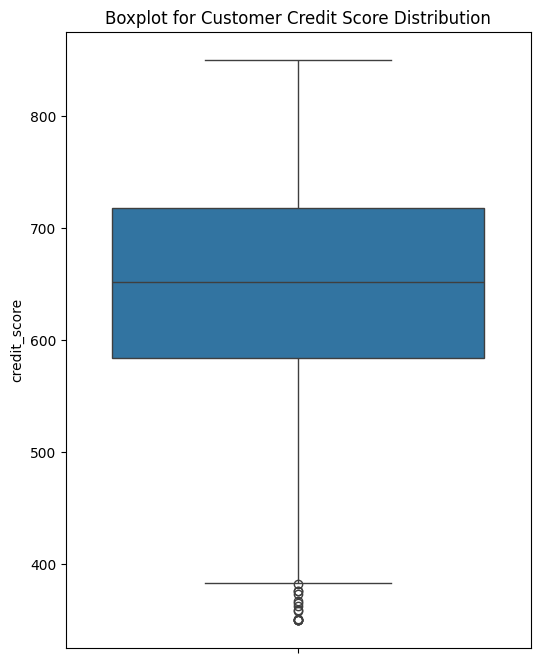

In [131]:
#Spread of customer credit score
plt.figure(figsize=(6, 8))
sns.boxplot(data=df['credit_score'], orient='v')
plt.title('Boxplot for Customer Credit Score Distribution')
plt.xticks(rotation=45)
plt.show()
#IQR for credit score is between 584 and 718. Scores below ~400 are flagged as outliers.

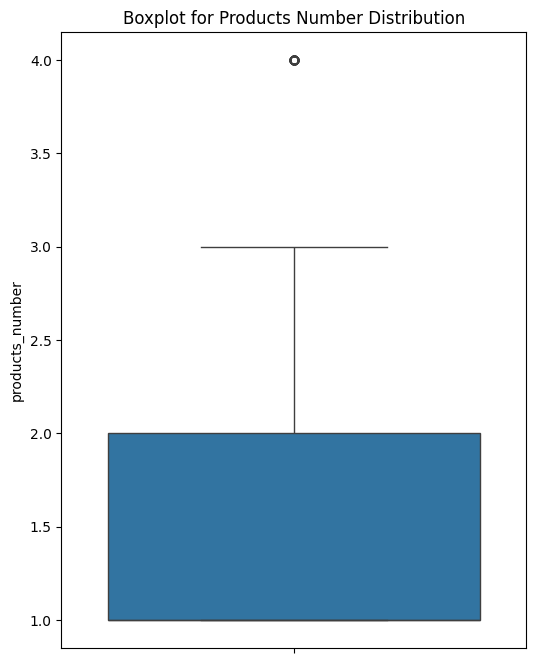

In [133]:
#Spread of how many bank products customers have
plt.figure(figsize=(6, 8))
sns.boxplot(data=df['products_number'], orient="v")
plt.title("Boxplot for Products Number Distribution")
plt.xticks(rotation=45)
plt.show()
#Almost all customers have either 1 or 2 products. Customers with 4 products are flagged as outliers.

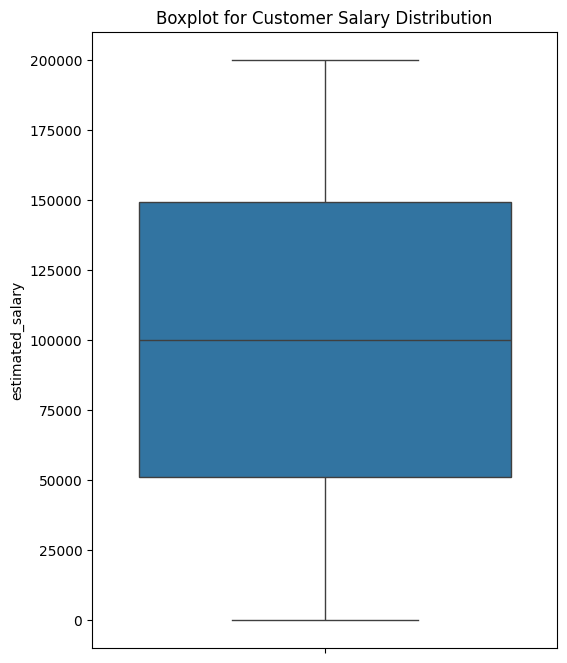

In [135]:
#Spread of customer salary
plt.figure(figsize=(6, 8))
sns.boxplot(data=df['estimated_salary'], orient='v')
plt.title('Boxplot for Customer Salary Distribution')
plt.xticks(rotation=45)
plt.show()
#IQR for salary is approximately 50,000 to 150,000. There are no outliers.

Let's further examine the unusually low salaries flagged in the describe output.

In [138]:
df[df['estimated_salary'] < 1000]

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
149,15794413,416,France,Male,32,0,0.00,2,0,1,878.87,0
195,15594815,807,France,Male,35,3,174790.15,1,1,1,600.36,0
393,15684548,556,Spain,Male,38,8,0.00,2,0,0,417.41,1
396,15584766,557,France,Male,33,3,54503.55,1,1,1,371.05,0
559,15571816,850,Spain,Female,70,5,0.00,1,1,1,705.18,0
925,15636731,714,Germany,Female,36,1,101609.01,2,1,1,447.73,0
932,15634141,708,Germany,Female,42,8,192390.52,2,1,0,823.36,0
982,15792360,668,France,Male,32,7,0.00,2,1,1,777.37,0
1139,15569247,727,Spain,Female,57,1,109679.72,1,0,1,753.37,0
1451,15684198,551,France,Female,38,10,0.00,2,1,1,216.27,0


In [140]:
df[df['estimated_salary'] < 1000].shape[0]

59

59 of 10,000 customers have annual salaries under £1,000. Inspecting these rows shows a mixed picture — some carry zero balance while others have balances above £80,000, making a single blanket explanation unlikely. These records could reflect data entry errors, recent unemployment, seasonal income, or unpaid leave. Since there is no way to verify with the data source, and since the salary variable shows negligible correlation with churn (confirmed in the statistical tests below), these records are retained without modification. Dropping 59 rows (<0.6% of the dataset) would have minimal impact on model performance.

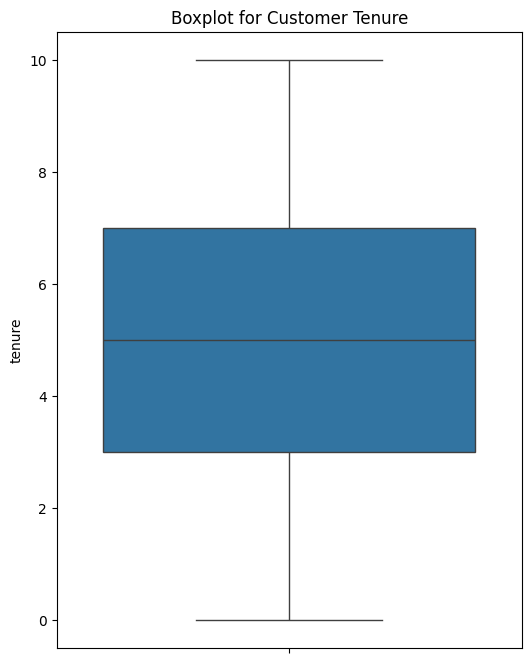

In [143]:
#Spread of customer tenure with bank
plt.figure(figsize=(6, 8))
sns.boxplot(data=df['tenure'], orient='v')
plt.title('Boxplot for Customer Tenure')
plt.xticks(rotation=45)
plt.show()
#IQR for tenure is 3-7 years. There are no outliers.

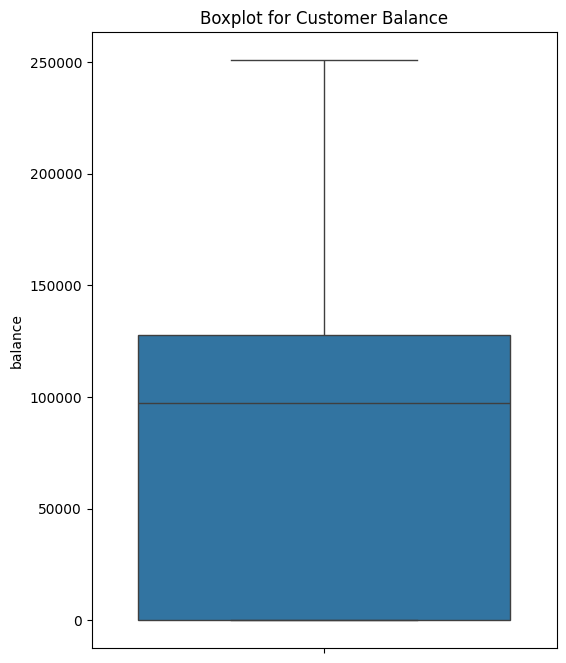

In [145]:
#Spread of customer bank account balance
plt.figure(figsize=(6, 8))
sns.boxplot(data=df['balance'], orient='v')
plt.title('Boxplot for Customer Balance')
plt.xticks(rotation=45)
plt.show()

**Note on balance distribution:** The boxplot shows an IQR spanning £0 to approximately £127,000, with no statistical outliers — but this obscures an important structural feature of the data. A large proportion of customers carry exactly £0 balance, creating a bimodal distribution rather than a continuous one. The cell below quantifies this.

This has implications for downstream analysis: the balance correlation coefficient and t-test both assume an approximately unimodal continuous distribution, so their results for balance should be interpreted with this caveat in mind. In a more extended analysis, a binary `has_balance` feature could be engineered to capture this distinction more cleanly alongside the raw balance value.

In [148]:
#Quantify the zero-balance customer segment
zero_balance = (df['balance'] == 0).sum()
print(f"Customers with zero balance: {zero_balance} ({zero_balance/len(df):.1%})")
print(f"Customers with non-zero balance: {len(df) - zero_balance} ({(len(df)-zero_balance)/len(df):.1%})")

Customers with zero balance: 3617 (36.2%)
Customers with non-zero balance: 6383 (63.8%)


#### Examining the distribution of binary and categorical variables

In [151]:
#Customer country
Country_of_Residence = df['country'].value_counts()
Country_of_Residence

country
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Text(0.5, 1.0, 'Customer Country/Location')

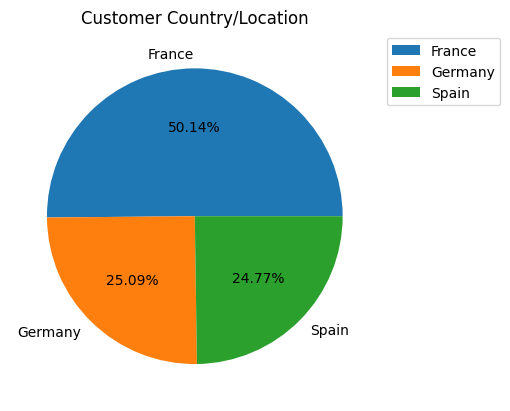

In [153]:
plt.pie(Country_of_Residence,labels=Country_of_Residence.index,autopct='%0.2f%%')
plt.legend(bbox_to_anchor=(1.0,1))
plt.title('Customer Country/Location')
#Over half of the bank's customers are located in France.

In [155]:
#Customer gender
Sex = df['gender'].value_counts()
Sex

gender
Male      5457
Female    4543
Name: count, dtype: int64

Text(0.5, 1.0, 'Customer Sex')

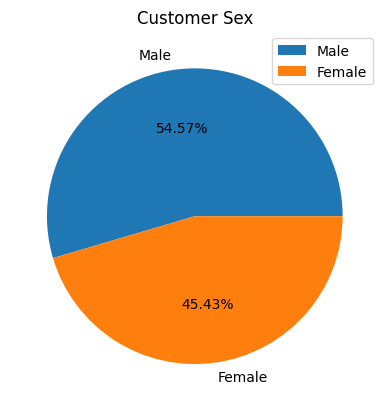

In [157]:
plt.pie(Sex,labels=Sex.index,autopct='%0.2f%%')
plt.legend(bbox_to_anchor=(1.0,1))
plt.title('Customer Sex')
#It is close to an even split, with slightly more than half of customers being men.

In [159]:
#Whether a customer has a credit card with the bank
CC = df['credit_card'].value_counts()
CC.index = CC.index.map({1: "Yes", 0: "No"})
CC

credit_card
Yes    7055
No     2945
Name: count, dtype: int64

Text(0.5, 1.0, 'Customers with Bank Credit Card')

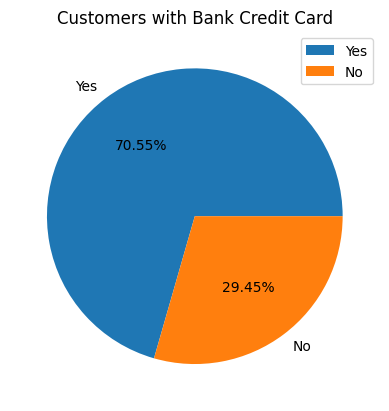

In [161]:
plt.pie(CC,labels=CC.index,autopct='%0.2f%%')
plt.legend(bbox_to_anchor=(1.0,1))
plt.title('Customers with Bank Credit Card')
#Over 2/3 of customers have a credit card with the bank

In [163]:
#Whether customer is an active member of the bank
active = df['active_member'].value_counts()
active.index = active.index.map({1: "Yes", 0: "No"})
active

active_member
Yes    5151
No     4849
Name: count, dtype: int64

Text(0.5, 1.0, 'Customers with Active Membership')

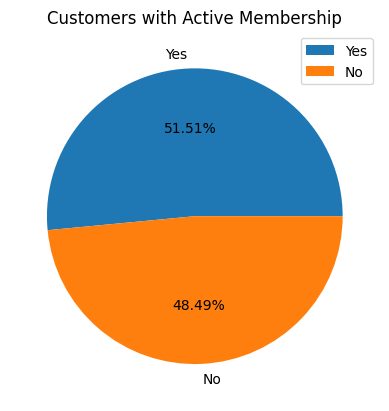

In [165]:
plt.pie(active,labels=active.index,autopct='%0.2f%%')
plt.legend(bbox_to_anchor=(1.0,1))
plt.title('Customers with Active Membership')
#It is close to a 50/50 split.

In [167]:
Churn = df['churn'].value_counts()
Churn.index = Churn.index.map({1: "Yes", 0: "No"})
Churn

churn
No     7963
Yes    2037
Name: count, dtype: int64

Text(0.5, 1.0, 'Customers that Churn')

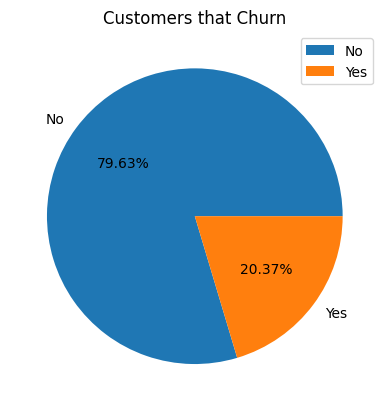

In [169]:
plt.pie(Churn,labels=Churn.index,autopct='%0.2f%%')
plt.legend(bbox_to_anchor=(1.0,1))
plt.title('Customers that Churn')
#Only about one in five customers leaves the bank.

Customer churn is the primary variable of interest. We want to assess the relationship between all other variables in the dataset and how they may influence the likelihood of churn.

#### Exploring Correlation

In [173]:
# Create a copy of the original dataframe for encoding.
# The original df is preserved for EDA visualisations that use string labels (e.g. country, gender).
# Encoding is applied to encoded_df only, which will be used for correlation analysis and modeling.
encoded_df = df.copy()

In [175]:
categorical_columns = encoded_df.select_dtypes(include=['object']).columns
categorical_columns

Index(['country', 'gender'], dtype='object')

In [177]:
# Binary encode gender (legitimate — Male/Female is dichotomous).
# LabelEncoder sorts alphabetically: Female = 0, Male = 1.
enc = LabelEncoder()
encoded_df['gender'] = enc.fit_transform(encoded_df['gender'])

# One-hot encode country (nominal variable — label encoding would imply a false ordinal relationship: France < Germany < Spain).
# drop_first=True drops France, making it the reference category. Germany and Spain coefficients are therefore interpreted relative to France.
encoded_df = pd.get_dummies(encoded_df, columns=['country'], drop_first=True)

# Cast boolean dummy columns to int to avoid dtype issues in sklearn and the heatmap
country_cols = [c for c in encoded_df.columns if c.startswith('country_')]
encoded_df[country_cols] = encoded_df[country_cols].astype(int)

encoded_df.head()

,customer_id,credit_score,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_Germany,country_Spain
0,15634602,619,0,42,2,0.00,1,1,1,101348.88,1,0,0
1,15647311,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1
2,15619304,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0
3,15701354,699,0,39,1,0.00,2,0,0,93826.63,0,0,0
4,15737888,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1


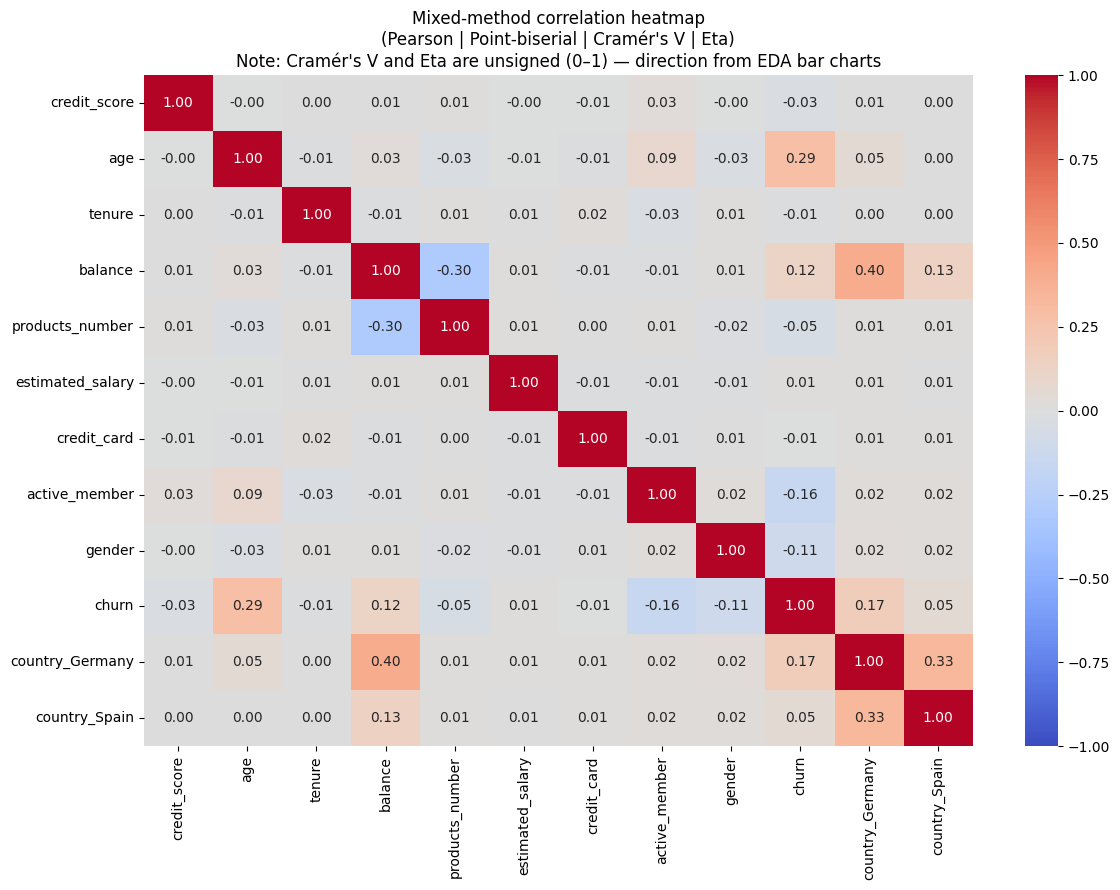

In [179]:
# Cramér's V is chosen here because it is the standard measure for nominal vs nominal or nominal vs binary pairs.
# The definition measures the strength of association between two categorical variables by running a chi-square test on their frequency table, 
# then normalising the result for sample size and number of categories to produce a score between 0 and 1. 
def cramers_v(x, y):
    """Cramér's V for nominal vs nominal or nominal vs binary pairs.
    Guard clause prevents misuse with continuous variables."""
    if not (x.nunique() <= 10 and y.nunique() <= 10):
        raise ValueError(
            f"Cramér's V requires categorical inputs. "
            f"Got {x.name} (nunique={x.nunique()}) and {y.name} (nunique={y.nunique()})"
        )
    contingency = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(contingency)[0]
    n = contingency.sum().sum()
    phi2 = chi2 / n
    r, k = contingency.shape
    return np.sqrt(phi2 / min(k - 1, r - 1))

# Eta is chosen here because it correctly handles the nominal vs continuous case that neither Pearson, point-biserial, 
# nor Cramér's V are designed for — without it, the heatmap was incorrectly applying Cramér's V to continuous variables.
# The definition measures how much of the variance in a continuous variable is explained by a categorical grouping, 
# by comparing how far each group's mean sits from the overall mean against the total spread of the data, returning a 0–1 score. 
def eta(categorical, continuous):
    """Eta for nominal vs continuous pairs.
    Returns eta (not eta²) to keep scale consistent with other measures (0–1, unsigned)."""
    groups = [continuous[categorical == cat] for cat in categorical.unique()]
    grand_mean = continuous.mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    ss_total = sum((continuous - grand_mean) ** 2)
    return np.sqrt(ss_between / ss_total)

# Pearson and Point-Biserial correlation measures are already implemented in standard libraries; no need to write custom functions.

# Drop customer_id — index column, not a predictor
corr_df = encoded_df.drop(columns=['customer_id'], errors='ignore')

# Classify columns by type
# country_Germany, country_Spain: nominal dummies (relative to France as reference)
# credit_card, active_member, gender, churn: binary
# all others: continuous
nominal_cols    = [c for c in corr_df.columns if c.startswith('country_')]
binary_cols     = ['credit_card', 'active_member', 'gender', 'churn']
continuous_cols = [c for c in corr_df.columns
                   if c not in nominal_cols and c not in binary_cols]

all_cols = continuous_cols + binary_cols + nominal_cols
n_cols = len(all_cols)
matrix = pd.DataFrame(np.ones((n_cols, n_cols)), index=all_cols, columns=all_cols)

for col_a, col_b in itertools.combinations(all_cols, 2):
    a_nom = col_a in nominal_cols
    b_nom = col_b in nominal_cols
    a_con = col_a in continuous_cols
    b_con = col_b in continuous_cols

    if a_nom and b_nom:
        val = cramers_v(corr_df[col_a], corr_df[col_b])     # nominal vs nominal
    elif a_nom and b_con:
        val = eta(corr_df[col_a], corr_df[col_b])            # nominal vs continuous
    elif b_nom and a_con:
        val = eta(corr_df[col_b], corr_df[col_a])            # continuous vs nominal
    elif a_nom or b_nom:
        val = cramers_v(corr_df[col_a], corr_df[col_b])     # nominal vs binary
    elif col_a in binary_cols or col_b in binary_cols:
        val, _ = pointbiserialr(corr_df[col_a], corr_df[col_b])  # binary vs continuous/binary
    else:
        val = corr_df[col_a].corr(corr_df[col_b])           # continuous vs continuous

    matrix.loc[col_a, col_b] = val
    matrix.loc[col_b, col_a] = val

plt.figure(figsize=(12, 9))
sns.heatmap(matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title("Mixed-method correlation heatmap\n"
          "(Pearson | Point-biserial | Cramér's V | Eta)\n"
          "Note: Cramér's V and Eta are unsigned (0–1) — direction from EDA bar charts")
plt.tight_layout()
plt.show()

**Interpreting the heatmap**

Three correlation methods are used, matched to each variable pair type:
- **Pearson** — continuous vs continuous (e.g. age vs credit_score)
- **Point-biserial** — binary vs continuous, or binary vs binary (e.g. churn vs age)
- **Cramér's V** — nominal vs nominal, or nominal vs binary (e.g. country vs churn)
- **Eta** — nominal vs continuous (e.g. country vs balance), avoiding the prior bug where Cramér's V was incorrectly applied to continuous inputs

**Key findings from the churn row/column:**

- **Age (0.29)** is the strongest predictor — older customers are more likely to churn
- **Active member (−0.16)** is the second strongest — active members are less likely to churn
- **Country Germany (0.17, Cramér's V)** shows moderate association with churn
- **Balance (0.12)** shows modest positive association; higher balance customers are more likely to churn
- **Gender (−0.11)** shows modest negative association; since LabelEncoder assigns Female=0 and Male=1 alphabetically, a negative coefficient means male customers are less likely to churn
- **Products number (−0.05)**, credit score, tenure, and estimated salary show negligible *linear* association with churn. Note that products number's weak linear coefficient does not rule out a non-linear effect — as will be seen later in the SHAP analysis

**Important caveat:** Cramér's V and Eta are unsigned (always ≥ 0). They measure association strength only — direction must be read from the EDA bar charts and boxplots above. Do not compare their values directly against signed Pearson or point-biserial coefficients.

#### Univariate and Multivariate Relationships with Customer Churn

Age is a continuous integer variable, but binning it into categories allows us to visually assess whether distinct age ranges have meaningfully different churn rates, and to explore interactions between age and other variables (e.g. gender, country).

Age bins are created only on the original `df` dataframe so they do not enter the predictive model — the model uses raw age as a continuous feature, which preserves more information.

In [184]:
age_bins = [17, 24, 39, 64, 95]  # lower bound 17 so age 18 falls correctly in the '18-24' bin
bin_labels = ['18-24', '25-39', '40-64', '65-95']

In [186]:
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=bin_labels)

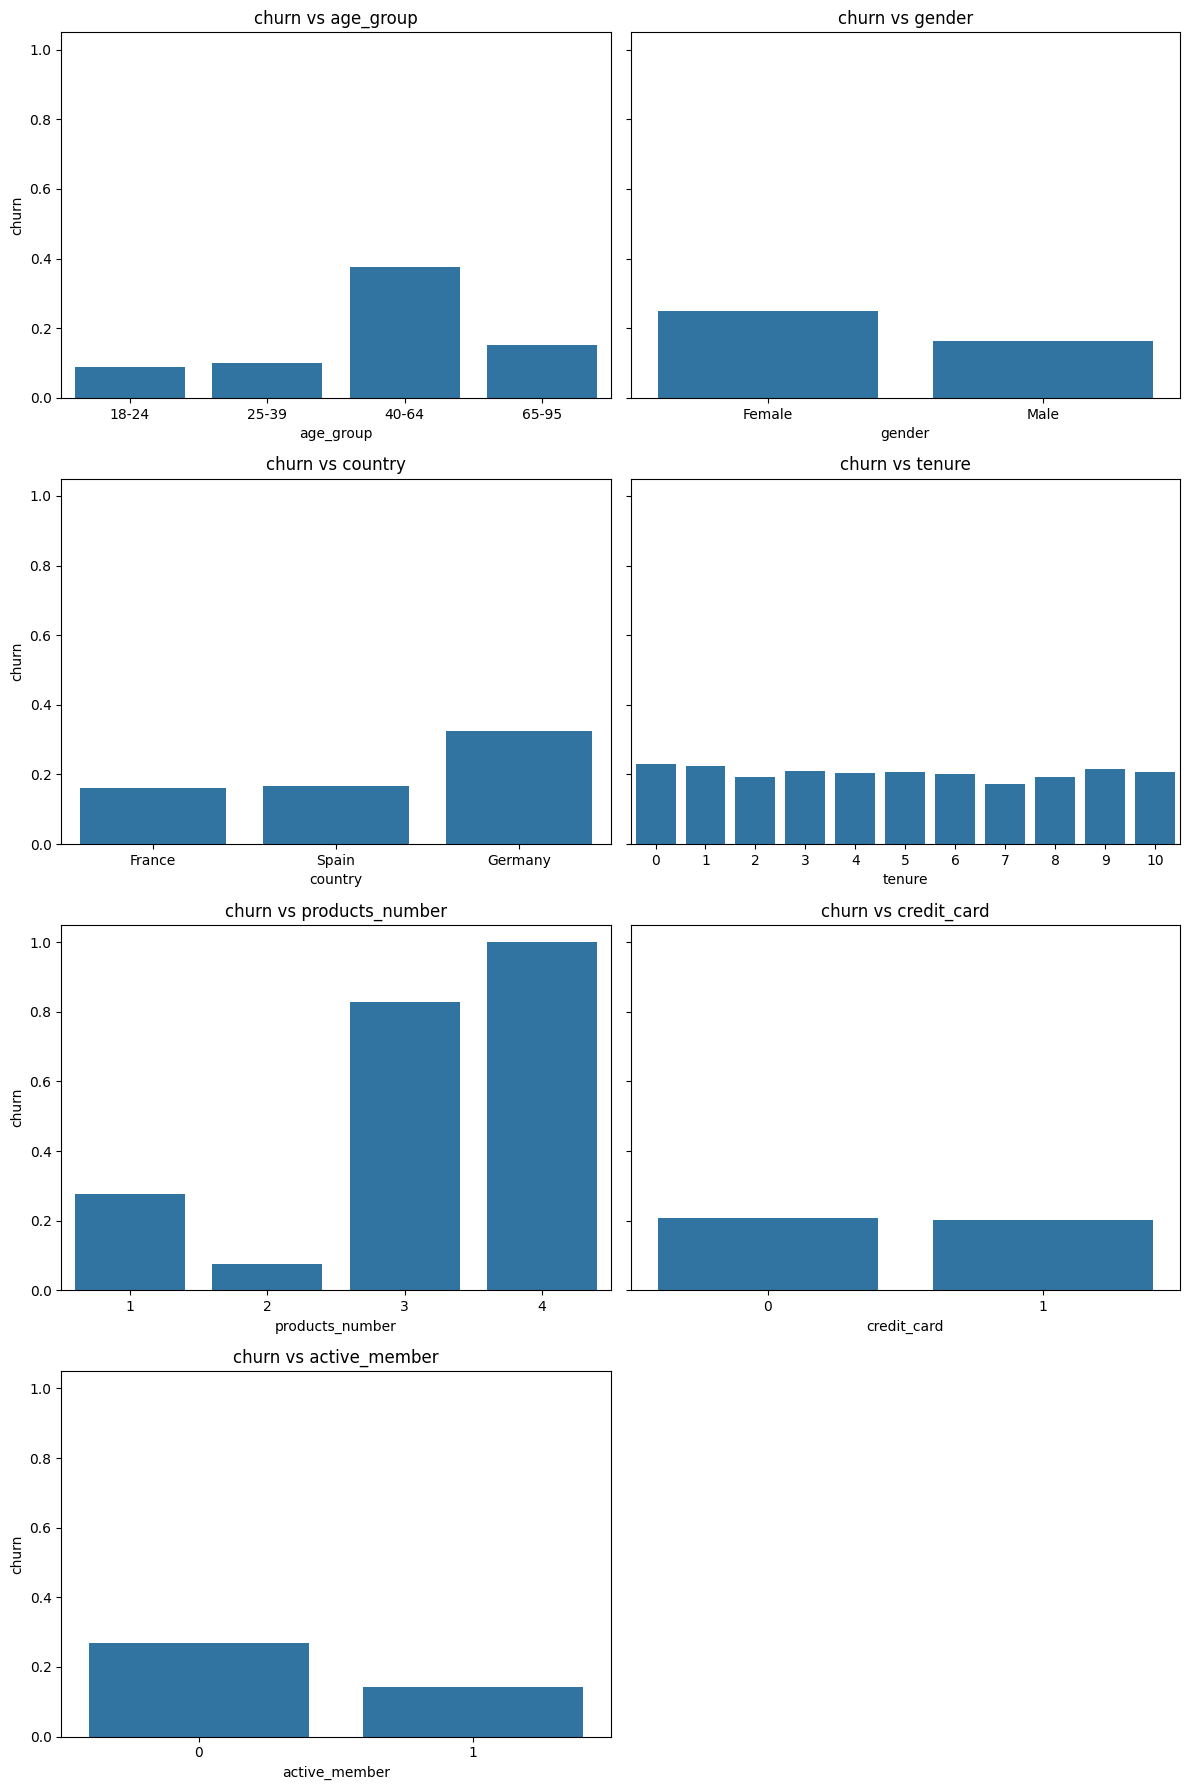

In [188]:
x_vars = ['age_group', 'gender', 'country', 'tenure', 'products_number', 'credit_card', 'active_member']
y_var = 'churn'

fig, axes = plt.subplots(4, 2, figsize=(12, 18), sharey=True)
axes = axes.flatten()

for ax, x in zip(axes, x_vars):
    sns.barplot(x=x, y=y_var, data=df, errorbar=None, ax=ax)
    ax.set_title(f'{y_var} vs {x}')

for ax in axes[len(x_vars):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

Univariate comparisons show that the 40–64 age group, female gender, German residency, higher product number (3–4), and non-active membership are each more strongly associated with customer churn than other categories within those fields.

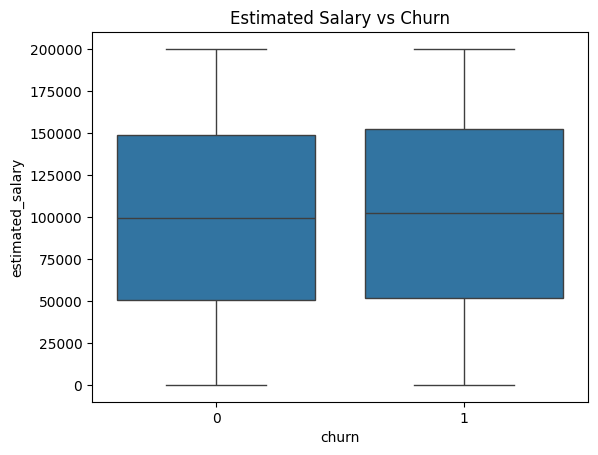

In [190]:
#Churn vs. Estimated Salary
sns.boxplot(data=df, x='churn', y='estimated_salary')
plt.title('Estimated Salary vs Churn')
plt.show()
#No noticeable relationship — consistent with near-zero correlation.

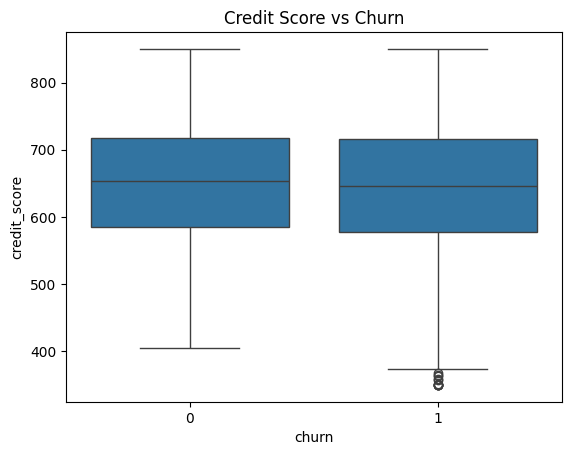

In [193]:
#Churn vs. Credit Score
sns.boxplot(data=df, x='churn', y='credit_score')
plt.title('Credit Score vs Churn')
plt.show()

The IQR does not differ substantially between churn and non-churn customers, suggesting credit score has limited linear discriminating power overall — consistent with its modest correlation value (−0.03) in the heatmap. However, credit score outliers below ~400 appear exclusively in the churn group, indicating that very low credit scores may be a meaningful risk signal at the extreme end of the distribution. These customers are retained in the dataset rather than dropped, as removing them would discard potentially informative at-risk cases. The non-linear threshold effect suggested here is one reason tree-based models are well-suited to this dataset.

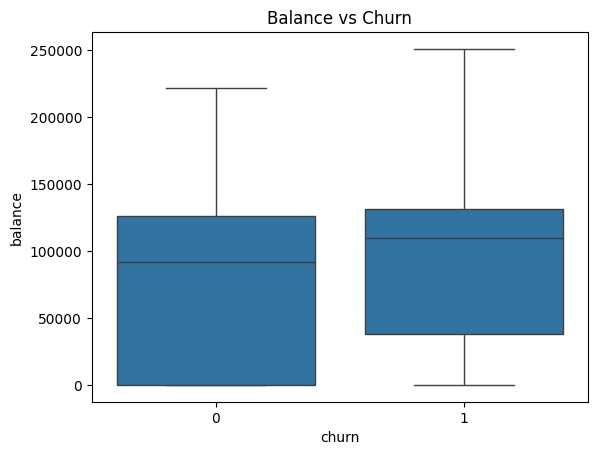

In [196]:
#Churn vs. Balance
sns.boxplot(data=df, x="churn", y="balance")
plt.title('Balance vs Churn')
plt.show()
#Churned customers have a noticeably higher median balance than non-churned customers.

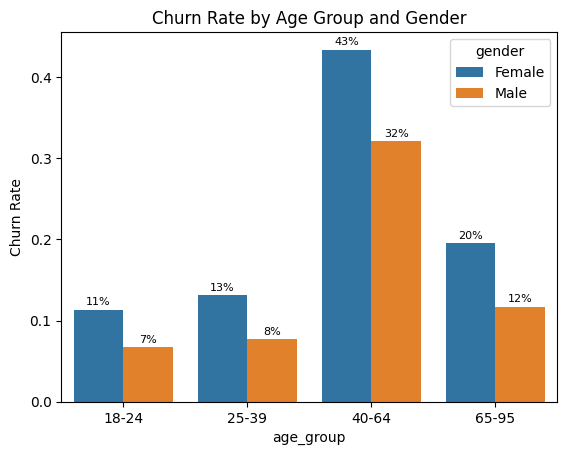

In [198]:
age_bar = sns.barplot(x='age_group', y='churn', hue='gender', data=df, errorbar=None)
for p in age_bar.patches:
    height = p.get_height()
    if height > 0:
        age_bar.annotate(f"{height:.0%}",
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=8, color="black", xytext=(0, 2),
                textcoords='offset points')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Age Group and Gender')
plt.show()

The 40–64 age group has the highest churn rate: over 30% of men and over 40% of women in this bracket leave the bank. The gender gap is consistent across age groups, with women churning at a higher rate in every category.

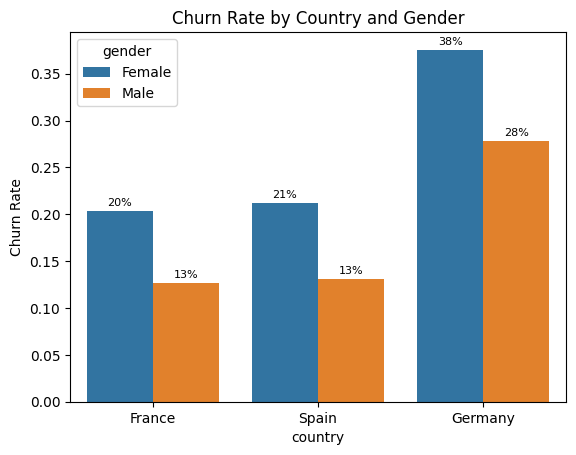

In [201]:
country_bar = sns.barplot(x='country', y='churn', hue='gender', data=df, errorbar=None)
for p in country_bar.patches:
    height = p.get_height()
    if height > 0:
        country_bar.annotate(f"{height:.0%}",
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=8, color="black", xytext=(0, 2),
                textcoords="offset points")
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Country and Gender')
plt.show()

German customers churn at a substantially higher rate than French or Spanish customers. The gender effect is also present in Germany, with female German customers showing the highest churn rate of any country-gender combination.

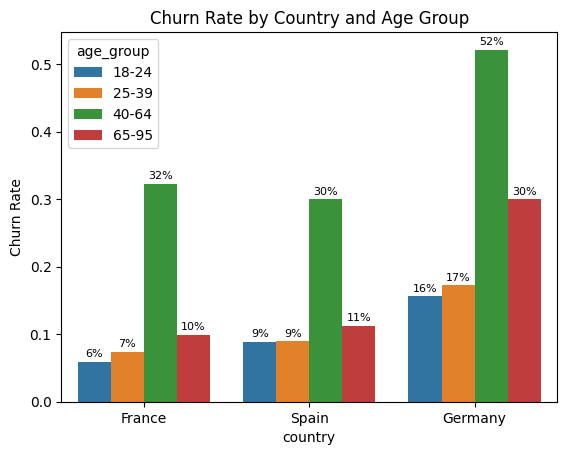

In [204]:
country_bar2 = sns.barplot(x='country', y='churn', hue='age_group', data=df, errorbar=None)
for p in country_bar2.patches:
    height = p.get_height()
    if height > 0:
        country_bar2.annotate(f"{height:.0%}",
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=8, color="black", xytext=(0, 2),
                textcoords='offset points')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Country and Age Group')
plt.show()
# 40-64 year old customers in Germany have a churn rate exceeding 50%

### Statistical Tests

Formal tests are used to confirm which variables have a statistically significant association with churn, and to correct for the risk of false positives when testing multiple features simultaneously.

##### Chi-Square Test for Categorical Variables

Chi-square tests are appropriate for assessing independence between two categorical variables. Here we test each categorical feature against the binary churn outcome. The test requires that all expected cell frequencies are ≥ 5, which is verified below.

In [208]:
categorical_features = ['country', 'gender', 'credit_card', 'active_member']

chi2_results = []

for col in categorical_features:
    contingency_table = pd.crosstab(df[col], df['churn'])
    chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
    chi2_results.append({'feature': col, 'chi2_stat': chi2, 'p_value': p})

chi2_df = pd.DataFrame(chi2_results).sort_values('p_value')
chi2_df

,feature,chi2_stat,p_value
0,country,301.255337,3.830318e-66
3,active_member,242.985342,8.785858e-55
1,gender,112.918571,2.248210e-26
2,credit_card,0.471338,4.923724e-01


In [210]:
# Verify chi-square assumption: all expected cell frequencies must be >= 5
print("Minimum expected cell frequencies per feature:")
min_expected = {}
for col in categorical_features:
    ct = pd.crosstab(df[col], df['churn'])
    _, _, _, expected = stats.chi2_contingency(ct)
    min_expected[col] = expected.min()
    print(f"  {col}: {min_expected[col]:.1f}")

if all(v >= 5 for v in min_expected.values()):
    print("\nAll values >= 5 — chi-square assumptions are met.")
else:
    failed = [col for col, v in min_expected.items() if v < 5]
    print(f"\nWARNING: The following features have expected frequencies below 5: {failed}")
    print("Chi-square results for these features should be interpreted with caution.")

Minimum expected cell frequencies per feature:
  country: 504.6
  gender: 925.4
  credit_card: 599.9
  active_member: 987.7

All values >= 5 — chi-square assumptions are met.


In [212]:
# Correct for multiple comparisons using Benjamini-Hochberg FDR
# BH is preferred over Bonferroni for feature screening as it is less conservative.
raw_p = chi2_df['p_value'].values
reject, p_corrected, _, _ = multipletests(raw_p, method='fdr_bh')

chi2_df['p_value_corrected'] = p_corrected
chi2_df['reject_null'] = reject
chi2_df

,feature,chi2_stat,p_value,p_value_corrected,reject_null
0,country,301.255337,3.830318e-66,1.532127e-65,True
3,active_member,242.985342,8.785858e-55,1.757172e-54,True
1,gender,112.918571,2.248210e-26,2.997613e-26,True
2,credit_card,0.471338,4.923724e-01,4.923724e-01,False


After correcting for multiple comparisons, country, active_member, and gender each have a statistically significant association with churn. Credit card does not. This is consistent with its near-zero correlation value in the heatmap.
Note that with 4 tests and three highly significant results, the correction here is good practice, rather than a consequential analytical decision.

##### Welch's T-Test for Numerical Variables

Welch's t-test (equal_var=False) is used rather than Student's t-test because the two groups (churned vs non-churned) have markedly unequal sizes (2,037 vs 7,963). Welch's test does not assume equal variances, making it more appropriate here.

Note: `products_number` is technically ordinal (values 1–4) and a Kruskal-Wallis test would be more rigorous for it. It is included here for consistency.

In [216]:
excluded_cols = ['churn', 'customer_id', 'credit_card', 'active_member']

numeric_features = df.select_dtypes(include=['int64', 'float64']).columns
numeric_features = [col for col in numeric_features if col not in excluded_cols]

t_test_results = []

for col in numeric_features:
    group0 = df[df['churn'] == 0][col]
    group1 = df[df['churn'] == 1][col]
    t_stat, p_value = stats.ttest_ind(group0, group1, equal_var=False, nan_policy='omit')
    t_test_results.append({'feature': col, 't_stat': t_stat, 'p_value': p_value})

t_test_df = pd.DataFrame(t_test_results).sort_values('p_value')
t_test_df

,feature,t_stat,p_value
1,age,-30.419197,4.712727e-179
3,balance,-12.471280,6.318664e-35
4,products_number,3.701998,2.185849e-04
0,credit_score,2.634661,8.464729e-03
2,tenure,1.384329,1.663570e-01
5,estimated_salary,-1.203368,2.289246e-01


In [218]:
raw_p = t_test_df['p_value'].values
reject_fdr, p_fdr, _, _ = multipletests(raw_p, method='fdr_bh')

t_test_df['p_fdr'] = p_fdr
t_test_df['reject_fdr'] = reject_fdr
t_test_df

,feature,t_stat,p_value,p_fdr,reject_fdr
1,age,-30.419197,4.712727e-179,2.827636e-178,True
3,balance,-12.471280,6.318664e-35,1.895599e-34,True
4,products_number,3.701998,2.185849e-04,4.371699e-04,True
0,credit_score,2.634661,8.464729e-03,1.269709e-02,True
2,tenure,1.384329,1.663570e-01,1.996284e-01,False
5,estimated_salary,-1.203368,2.289246e-01,2.289246e-01,False


Age, balance, products_number, and credit_score each have a statistically significant association with churn after FDR correction. Tenure and estimated_salary do not reject the null hypothesis and show no meaningful association with churn. As with the earlier chi square test, the correction here was done for good practice, rather than genuine need for correction.

### Feature Selection

Based on the statistical tests above, three features failed to show a significant association with churn:
- **credit_card** — chi-square p = 0.49 (not significant)
- **tenure** — Welch's t p = 0.17 (not significant)  
- **estimated_salary** — Welch's t p = 0.23 (not significant)

Before including all features in the model, it is good practice to test whether dropping these insignificant features degrades predictive performance. If the reduced model performs similarly, it is preferred — a simpler model is easier to interpret, less likely to overfit, and faster to retrain.

We compare cross-validated ROC AUC between the full feature set and the reduced set.

### Model Preparation

In [221]:
# Drop customer_id — serves only as a row index, not a predictor
encoded_df = encoded_df.drop('customer_id', axis=1)

# Safety check: age_group was added to df after encoded_df was copied so it should not be present. If cells are re-run out of order this
# assertion catches accidental leakage before it reaches the model.
assert 'age_group' not in encoded_df.columns,     "age_group detected in encoded_df — this is derived from age and would cause leakage. Check cell execution order."

In [223]:
X = encoded_df.drop('churn', axis=1)
y = encoded_df['churn']
print("Features:", list(X.columns))

Features: ['credit_score', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'country_Germany', 'country_Spain']


In [225]:
# Stratified split preserves the 80/20 churn ratio in both train and test sets.
# Without stratify=y, random chance could produce a test set with a different
# churn rate, making evaluation metrics less reliable.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [227]:
print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_test shape:  {X_test.shape}')
print(f'y_test shape:  {y_test.shape}')

# Verify churn ratio is preserved in both sets
print(f'\nTrain churn rate: {y_train.mean():.3f}')
print(f'Test churn rate:  {y_test.mean():.3f}')

X_train shape: (8000, 11)
y_train shape: (8000,)
X_test shape:  (2000, 11)
y_test shape:  (2000,)

Train churn rate: 0.204
Test churn rate:  0.203


#### Feature Selection Test

Now that the train/test split is defined, we test whether dropping the three statistically insignificant features (credit_card, tenure, estimated_salary) meaningfully affects model performance. We use cross-validated ROC AUC as the comparison metric.

In [103]:
# Define features that failed significance tests — used in comparison below
insignificant_features = ['credit_card', 'tenure', 'estimated_salary']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Full model
RF_full = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
cv_full = cross_val_score(RF_full, X, y, cv=cv, scoring='roc_auc')

# Reduced model — drop insignificant features
X_reduced = X.drop(columns=insignificant_features)
RF_reduced_test = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
cv_reduced = cross_val_score(RF_reduced_test, X_reduced, y, cv=cv, scoring='roc_auc')

print(f"Full model CV AUC    ({X.shape[1]} features): {cv_full.mean():.3f} (+/- {cv_full.std():.3f})")
print(f"Reduced model CV AUC ({X_reduced.shape[1]} features): {cv_reduced.mean():.3f} (+/- {cv_reduced.std():.3f})")
diff = cv_full.mean() - cv_reduced.mean()
print(f"\nAUC difference: {diff:.4f}")
if abs(diff) < 0.005:
    print("Difference < 0.005 — reduced model is preferred (simpler, no meaningful performance loss).")
else:
    print("Difference >= 0.005 — full model is preferred (meaningful performance gain from additional features).")

Full model CV AUC    (11 features): 0.853 (+/- 0.005)
Reduced model CV AUC (8 features): 0.843 (+/- 0.005)

AUC difference: 0.0098
Difference >= 0.005 — full model is preferred (meaningful performance gain from additional features).


**Feature selection outcome:** If the AUC difference is less than 0.005, we proceed with the reduced feature set for the final model. If the full model retains a meaningful advantage, all features are kept.
Since the AUC diff = 0.0098 >= 0.005 threshold, the full model (11 features) is preferred. No features will be dropped. X_train and X_test remain on all 11 features.

In [242]:
print(f"Proceeding with all {X_train.shape[1]} features:")
print(list(X_train.columns))

Proceeding with all 11 features:
['credit_score', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'country_Germany', 'country_Spain']


#### Model Evaluation Function

The `evaluate_model` function is defined here for reuse across all models. It accepts an optional `y_prob` argument for probability-based ROC AUC. Using binary 0/1 predictions for AUC would underestimate the true area under the curve because it collapses the probability distribution to a single operating point.

In [247]:
def evaluate_model(y_test, y_pred, y_prob=None, model_name=""):
    """
    Print standard classification metrics and plot confusion matrix.
    y_prob: predicted probabilities for class 1 (churn). If provided, ROC AUC
            is computed from the full probability distribution (correct).
            If None, falls back to binary predictions with a warning.
    """
    if model_name:
        print(f"=== {model_name} ===")
    print(f"Accuracy:    {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision:   {precision_score(y_test, y_pred):.4f}")
    cm = confusion_matrix(y_test, y_pred)
    sensitivity = cm[1, 1] / (cm[1, 1] + cm[1, 0])
    specificity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
    print(f"Sensitivity: {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")
    if y_prob is not None:
        print(f"ROC AUC:     {roc_auc_score(y_test, y_prob):.4f}  (probability-based)")
    else:
        print(f"ROC AUC:     {roc_auc_score(y_test, y_pred):.4f}  "
              f"(WARNING: binary predictions used — this underestimates true AUC)")
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=['Predicted No', 'Predicted Yes'],
                yticklabels=['Actual No', 'Actual Yes'])
    plt.title(f"Confusion Matrix{' — ' + model_name if model_name else ''}")
    plt.show()

#### Baseline Random Forest

We first fit a baseline Random Forest with `class_weight='balanced'` to handle the 80/20 class imbalance at the model level. This adjusts the weight of each class inversely proportional to its frequency, effectively penalising the model more for missing a churner than for a false alarm.

In [249]:
RF = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
RF.fit(X_train, y_train)
y_pred_rf = RF.predict(X_test)
y_prob_rf  = RF.predict_proba(X_test)[:, 1]

=== Random Forest (baseline) ===
Accuracy:    0.8600
Precision:   0.7725
Sensitivity: 0.4423
Specificity: 0.9667
ROC AUC:     0.8515  (probability-based)


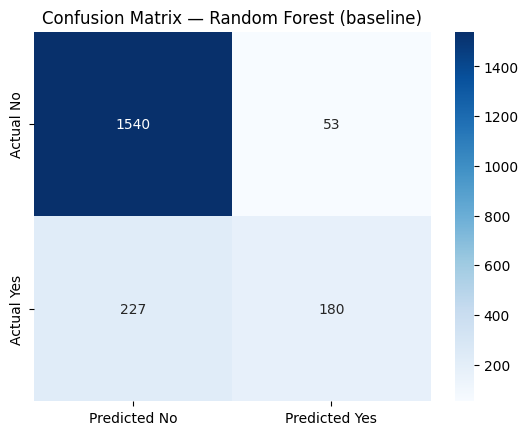

In [251]:
evaluate_model(y_test, y_pred_rf, y_prob=y_prob_rf, model_name="Random Forest (baseline)")

In [111]:
# 5-fold stratified cross-validation gives more reliable AUC estimates than a single split. 
# In 5-fold stratified cross-validation the data is split into 5 equal portions — the model is trained on 4 of them and evaluated 
# on the held-out 5th, then this is repeated 5 times so every observation gets used as a test case exactly once. 
# The 5 AUC scores are then averaged.
cv_scores = cross_val_score(RF, X, y, cv=cv, scoring='roc_auc')
print(f'Cross-validated ROC AUC: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})')

Cross-validated ROC AUC: 0.853 (+/- 0.005)


### Hyperparameter Tuning

The baseline Random Forest uses default hyperparameters. A randomised search over key parameters can meaningfully improve performance. We use `RandomizedSearchCV` rather than `GridSearchCV` — it samples a fixed number of parameter combinations randomly, which is faster and often finds near-optimal settings without exhaustive search.

Parameters tuned:
- `n_estimators` — number of trees (more trees = more stable predictions but slower)
- `max_depth` — maximum tree depth (controls overfitting)
- `min_samples_split` / `min_samples_leaf` — minimum samples required to split or form a leaf (controls overfitting)
- `max_features` — number of features considered at each split (controls diversity between trees)

In [258]:
param_dist = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_distributions=param_dist,
    n_iter=20,                   # test 20 random combinations
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,                   # use all available CPU cores
    verbose=1
)
rf_search.fit(X_train, y_train)
print("Best parameters:", rf_search.best_params_)
print(f"Best CV AUC:     {rf_search.best_score_:.3f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10}
Best CV AUC:     0.860


=== Random Forest (tuned) ===
Accuracy:    0.8325
Precision:   0.5750
Sensitivity: 0.6781
Specificity: 0.8719
ROC AUC:     0.8644  (probability-based)


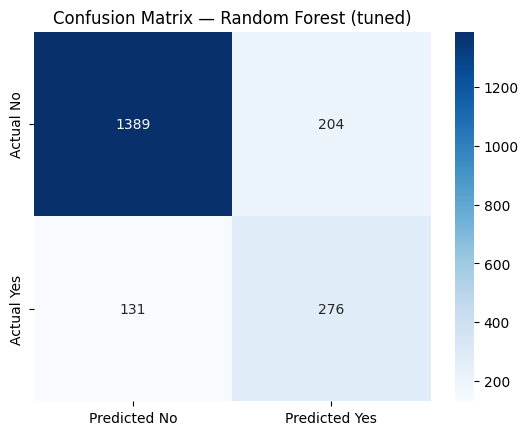

In [259]:
# Replace RF with the tuned estimator for all downstream steps
RF = rf_search.best_estimator_
y_pred_rf_tuned = RF.predict(X_test)
y_prob_rf_tuned  = RF.predict_proba(X_test)[:, 1]
evaluate_model(y_test, y_pred_rf_tuned, y_prob=y_prob_rf_tuned, model_name="Random Forest (tuned)")

The tuned model replaces the baseline for all subsequent analysis — SHAP values, PDPs, and the threshold adjustment below all use the tuned estimator.

### Model Comparison

We compare the tuned Random Forest against Logistic Regression and Gradient Boosting. To ensure a fair comparison:
- Logistic Regression receives scaled features (StandardScaler) and `class_weight='balanced'`
- Gradient Boosting does not have a `class_weight` parameter, so `sample_weight` is used to apply equivalent class balancing
- Random Forest uses the tuned estimator fitted above

In [262]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

models = {
    'Random Forest (tuned)': RF,
    'Logistic Regression':   LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Gradient Boosting':     GradientBoostingClassifier(n_estimators=100, random_state=42)
}

comparison_results = []
for name, model in models.items():
    X_tr = X_train_scaled if name == 'Logistic Regression' else X_train
    X_te = X_test_scaled  if name == 'Logistic Regression' else X_test

    if name == 'Gradient Boosting':
        # GBM has no class_weight — use sample_weight for equivalent class balancing
        sw = compute_sample_weight(class_weight='balanced', y=y_train)
        model.fit(X_tr, y_train, sample_weight=sw)
    else:
        model.fit(X_tr, y_train)

    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    cm     = confusion_matrix(y_test, y_pred)
    comparison_results.append({
        'Model':       name,
        'Accuracy':    round(accuracy_score(y_test, y_pred), 3),
        'Precision':   round(precision_score(y_test, y_pred), 3),
        'Sensitivity': round(cm[1,1] / (cm[1,1] + cm[1,0]), 3),
        'Specificity': round(cm[0,0] / (cm[0,0] + cm[0,1]), 3),
        'ROC AUC':     round(roc_auc_score(y_test, y_prob), 3)
    })

comparison_df = pd.DataFrame(comparison_results).set_index('Model')
print(comparison_df.to_string())

                       Accuracy  Precision  Sensitivity  Specificity  ROC AUC
Model                                                                        
Random Forest (tuned)     0.833      0.575        0.678        0.872    0.864
Logistic Regression       0.714      0.387        0.700        0.717    0.777
Gradient Boosting         0.800      0.506        0.759        0.810    0.869


**Model selection rationale**

From the comparison table above, Gradient Boosting achieves a marginally higher ROC AUC (0.869 vs 0.864) but lower overall accuracy (0.800 vs 0.833) than the tuned Random Forest. The AUC difference of 0.005 is at the threshold of practical significance.

We proceed with the tuned Random Forest for the following reasons:
1. `class_weight='balanced'` is handled natively — GBM required manual `sample_weight` to achieve equivalent class balancing, which adds complexity
2. `shap.TreeExplainer` is faster and more numerically stable on Random Forest than on GBM for this dataset size
3. The AUC difference is negligible and within the cross-validation variance band

**In a production context**, Gradient Boosting with full hyperparameter tuning (e.g. XGBoost or LightGBM with `scale_pos_weight`) would be the recommended approach given its consistent performance edge and typically superior calibration.

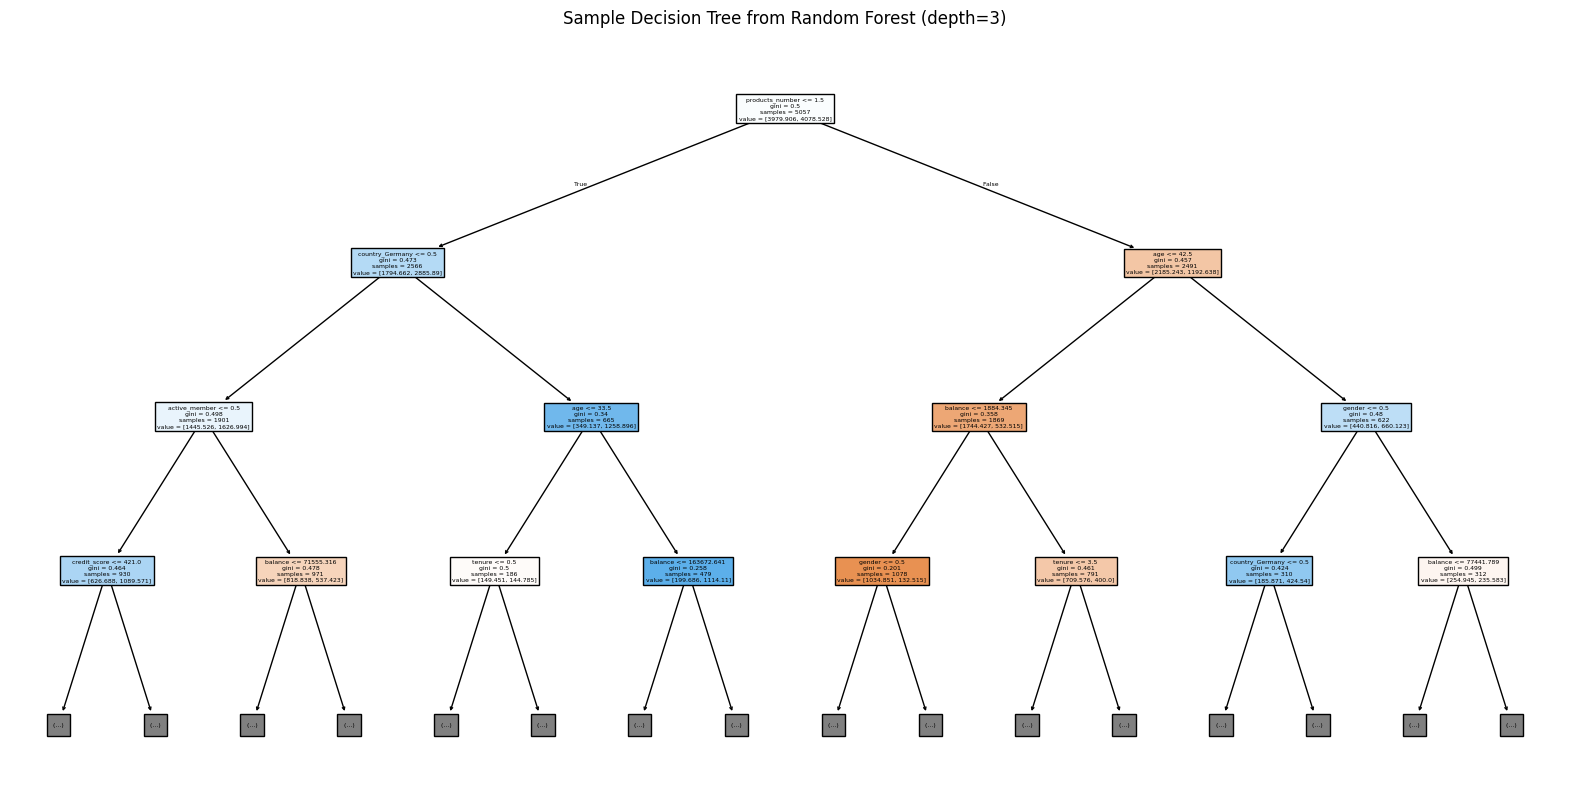

In [264]:
# Visualise one sample decision tree from the forest (max depth 3 for readability)
plt.figure(figsize=(20,10))
tree.plot_tree(RF.estimators_[0], feature_names=X_train.columns, max_depth=3, filled=True)
plt.title("Sample Decision Tree from Random Forest (depth=3)")
plt.show()

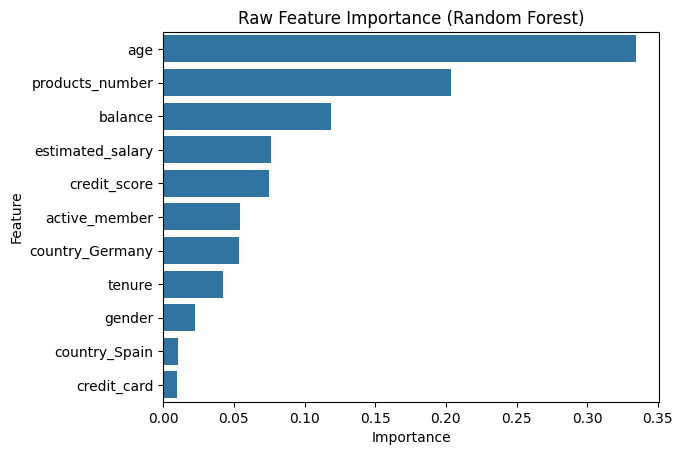

In [266]:
importances = RF.feature_importances_
feature_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

sns.barplot(data=feature_df, x='Importance', y='Feature')
plt.title('Raw Feature Importance (Random Forest)')
plt.show()

Age is the feature the Random Forest relies on most heavily for its splits, consistent with its highest correlation value against churn.

**Important caveat on raw feature importance:** Random Forest's built-in importance metric measures how frequently a feature is used for splits, weighted by the impurity reduction it achieves. This is known to overstate the importance of high-cardinality continuous variables (like estimated_salary and credit_score) relative to their true predictive contribution. SHAP values in the section below provide a more reliable individual-level measure and should be given precedence where the two disagree.

The tuned model's sensitivity at the default 0.5 threshold is **~68%** (Cell 86 output: 0.6781) — a meaningful improvement over the baseline's ~44%, attributable to hyperparameter tuning. However, one in three churners is still missed at this threshold. The following section selects a better operating threshold using principled methods rather than visual inspection of the curve.

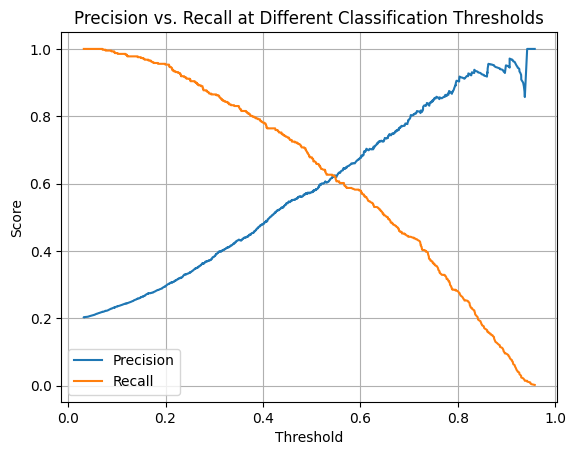

In [268]:
probs = RF.predict_proba(X_test)[:, 1]
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, probs)

plt.plot(thresholds, precision_vals[:-1], label='Precision')
plt.plot(thresholds, recall_vals[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.title('Precision vs. Recall at Different Classification Thresholds')
plt.grid()
plt.show()

#### Principled Threshold Selection

Two methods are used to find a better operating point. The code below computes both, visualises them on the precision-recall curve, and produces a side-by-side comparison table.

In [271]:
from sklearn.metrics import fbeta_score, roc_curve

# ── Method 1: Youden's J (maximises sensitivity + specificity simultaneously). Derived from the ROC curve — the point furthest from the 
#random diagonal. Treats FN and FP as equally costly. Best neutral/symmetric starting point.
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob_rf_tuned)
youden_j      = tpr - fpr
youden_idx    = np.argmax(youden_j)
youden_thresh = roc_thresholds[youden_idx]

y_pred_youden = (y_prob_rf_tuned >= youden_thresh).astype(int)
cm_y = confusion_matrix(y_test, y_pred_youden)
print(f"Youden's J optimal threshold: {youden_thresh:.3f}")
print(f"  Sensitivity: {cm_y[1,1]/(cm_y[1,1]+cm_y[1,0]):.3f}")
print(f"  Specificity: {cm_y[0,0]/(cm_y[0,0]+cm_y[0,1]):.3f}")
print(f"  Precision:   {precision_score(y_test, y_pred_youden):.3f}")

# ── Method 2: F-beta (β=2) — recall weighted twice as heavily as precision ────
# Appropriate when the cost of missing a churner > cost of a false alarm, which is the typical assumption in a retention context.
beta = 2
probs_for_thresh = RF.predict_proba(X_test)[:, 1]
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, probs_for_thresh)

fbeta_scores = []
for t in pr_thresholds:
    y_pred_t = (probs_for_thresh >= t).astype(int)
    fbeta_scores.append(fbeta_score(y_test, y_pred_t, beta=beta, zero_division=0))

fbeta_scores   = np.array(fbeta_scores)
best_fb_idx    = np.argmax(fbeta_scores)
fbeta_thresh   = pr_thresholds[best_fb_idx]

y_pred_fbeta   = (probs_for_thresh >= fbeta_thresh).astype(int)
cm_fb = confusion_matrix(y_test, y_pred_fbeta)
print(f"\nF{beta} optimal threshold: {fbeta_thresh:.3f}")
print(f"  Sensitivity: {cm_fb[1,1]/(cm_fb[1,1]+cm_fb[1,0]):.3f}")
print(f"  Specificity: {cm_fb[0,0]/(cm_fb[0,0]+cm_fb[0,1]):.3f}")
print(f"  Precision:   {precision_score(y_test, y_pred_fbeta):.3f}")

Youden's J optimal threshold: 0.438
  Sensitivity: 0.752
  Specificity: 0.829
  Precision:   0.529

F2 optimal threshold: 0.350
  Sensitivity: 0.830
  Specificity: 0.723
  Precision:   0.433


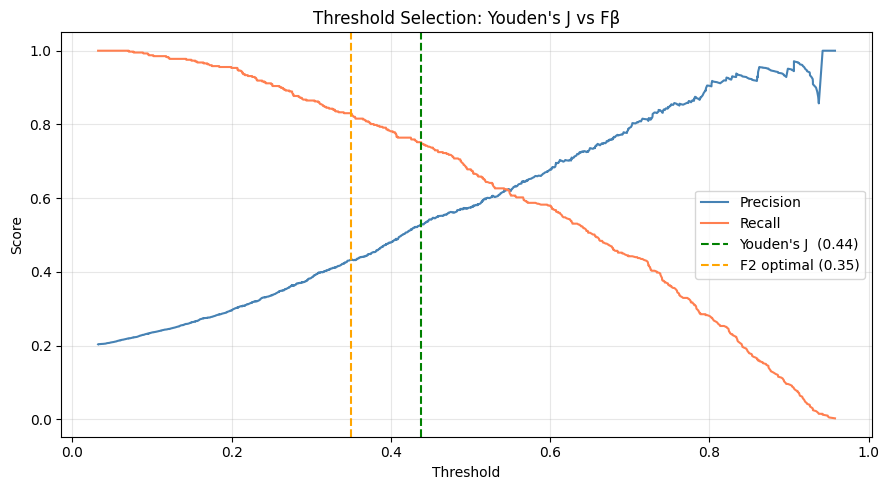

In [277]:
# ── Visualise both optimal thresholds on the precision-recall curve ───────────
plt.figure(figsize=(9, 5))
plt.plot(pr_thresholds, precision_vals[:-1], label='Precision', color='steelblue')
plt.plot(pr_thresholds, recall_vals[:-1],    label='Recall',    color='coral')
plt.axvline(youden_thresh,  color='green',  linestyle='--',
            label=f"Youden's J  ({youden_thresh:.2f})")
plt.axvline(fbeta_thresh,   color='orange', linestyle='--',
            label=f'F{beta} optimal ({fbeta_thresh:.2f})')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title("Threshold Selection: Youden's J vs F\u03b2")
plt.legend(loc='center right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [281]:
# ── Side-by-side comparison of all three thresholds ─────────────────────────
thresholds_to_compare = {
    f"Youden's J  ({youden_thresh:.2f})": youden_thresh,
    f"F{beta} optimal ({fbeta_thresh:.2f})": fbeta_thresh,
}

rows = []
for label, t in thresholds_to_compare.items():
    y_pred_t = (probs_for_thresh >= t).astype(int)
    cm_t     = confusion_matrix(y_test, y_pred_t)
    rows.append({
        'Threshold':        label,
        'Sensitivity':      round(cm_t[1,1]/(cm_t[1,1]+cm_t[1,0]), 3),
        'Specificity':      round(cm_t[0,0]/(cm_t[0,0]+cm_t[0,1]), 3),
        'Precision':        round(precision_score(y_test, y_pred_t), 3),
        'Accuracy':         round(accuracy_score(y_test, y_pred_t), 3),
        'False Positives':  int(cm_t[0,1]),
        'False Negatives':  int(cm_t[1,0])
    })

thresh_comparison = pd.DataFrame(rows).set_index('Threshold')
print(thresh_comparison.to_string())

                    Sensitivity  Specificity  Precision  Accuracy  False Positives  False Negatives
Threshold                                                                                          
Youden's J  (0.44)        0.752        0.829      0.529     0.814              272              101
F2 optimal (0.35)         0.830        0.723      0.433     0.745              442               69


**Choosing the operating threshold**

The comparison table above shows the two options. Key observations:

- **Youden's J** gives the most balanced sensitivity/specificity split — it is the right choice if false positives and false negatives are considered equally harmful
- **F₂ optimal** weights recall more heavily, producing higher sensitivity at the cost of more false positives — appropriate for churn where a missed customer costs more than an unnecessary retention contact

**Recommended threshold:** The F₂ optimal threshold is used for the final model evaluation below. It strikes a principled balance between catching churners and avoiding excessive false alarms, grounded in the business cost asymmetry rather than visual threshold selection. The confusion matrix and metrics below reflect this threshold.

In [285]:
# Apply the F-beta optimal threshold for final model evaluation
# This replaces the original manual 0.20 threshold
optimal_threshold = fbeta_thresh
y_pred_optimal    = (probs_for_thresh >= optimal_threshold).astype(int)
print(f"Final operating threshold (F{beta} optimal): {optimal_threshold:.3f}")
print(f"Sensitivity at this threshold: {recall_score(y_test, y_pred_optimal):.4f}")

Final operating threshold (F2 optimal): 0.350
Sensitivity at this threshold: 0.8305


The precision-recall curve shows the trade-off between catching more churners (recall/sensitivity) and the proportion of flagged customers who actually churn (precision). Rather than selecting a threshold by visual inspection, we use two principled methods below:

- **Youden's J statistic** — finds the threshold where sensitivity + specificity is maximised, treating false negatives and false positives as equally costly. A neutral, defensible default.
- **F-beta score (β=2)** — weights recall twice as heavily as precision, reflecting that missing a churner (lost revenue) typically costs more than a false alarm (unnecessary retention effort). More appropriate for churn specifically.

Both thresholds are computed below, plotted on the curve, and compared side-by-side against the original manual 0.20 threshold.

In [289]:
# Evaluate the model at the F-beta optimal threshold
# (optimal_threshold was computed in the threshold selection section above)
y_probs       = RF.predict_proba(X_test)[:, 1]
y_pred_thresh = (y_probs >= optimal_threshold).astype(int)
print(f"Threshold applied: {optimal_threshold:.3f}")
print(f"Sensitivity: {recall_score(y_test, y_pred_thresh):.4f}")

Threshold applied: 0.350
Sensitivity: 0.8305


=== Random Forest (Fβ optimal threshold = 0.35) ===
Accuracy:    0.7445
Precision:   0.4333
Sensitivity: 0.8305
Specificity: 0.7225
ROC AUC:     0.8644  (probability-based)


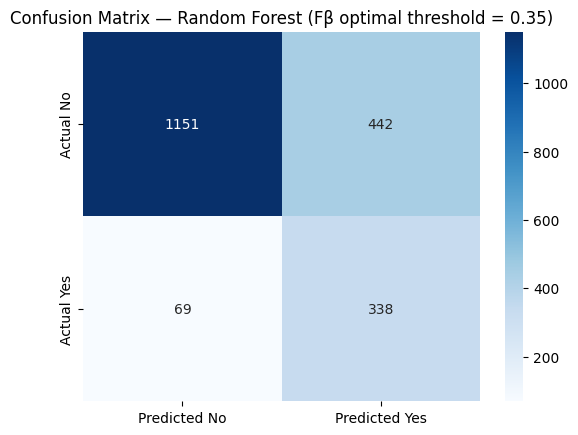

In [291]:
evaluate_model(y_test, y_pred_thresh, y_prob=y_probs,
              model_name=f"Random Forest (Fβ optimal threshold = {optimal_threshold:.2f})")

The comparison table above quantifies the trade-off between the three threshold candidates. The F₂ optimal threshold is selected as the final operating point because it reflects the business cost asymmetry — missing a churner costs more than a false retention contact.

At this threshold, sensitivity is meaningfully higher than the tuned model's default (68%). The ROC AUC remains 0.864 (probability-based) regardless of threshold, since AUC reflects the model's overall discriminatory power across all possible thresholds rather than performance at any single cut-point.

**Interpreting the confusion matrix:**
- **True Positives** — churners correctly flagged for retention intervention
- **False Positives** — non-churners unnecessarily flagged (wasted retention effort)
- **False Negatives** — churners missed entirely (revenue at risk)
- **True Negatives** — non-churners correctly left alone

The recommended retention strategy is to prioritise customers in the True Positive cell, particularly those with high churn probability scores well above the threshold — these represent the highest-confidence at-risk customers and should receive the most intensive intervention.

### Identifying High Risk Customers

SHAP (SHapley Additive exPlanations) values quantify each feature's contribution to an individual prediction. Unlike raw feature importance, SHAP accounts for feature interactions and produces signed contributions, showing not just which features matter, but in which direction and by how much for each customer.

We compute SHAP values on the full test set, then filter to the high-risk subset (churn probability ≥ optimal threshold) to understand what drives predictions for at-risk customers specifically.

In [298]:
import shap
explainer = shap.TreeExplainer(RF)
shap_values = explainer.shap_values(X_test)
print(f"SHAP values shape: {np.shape(shap_values)}")
# Shape: (n_samples, n_features, n_classes)

SHAP values shape: (2000, 11, 2)


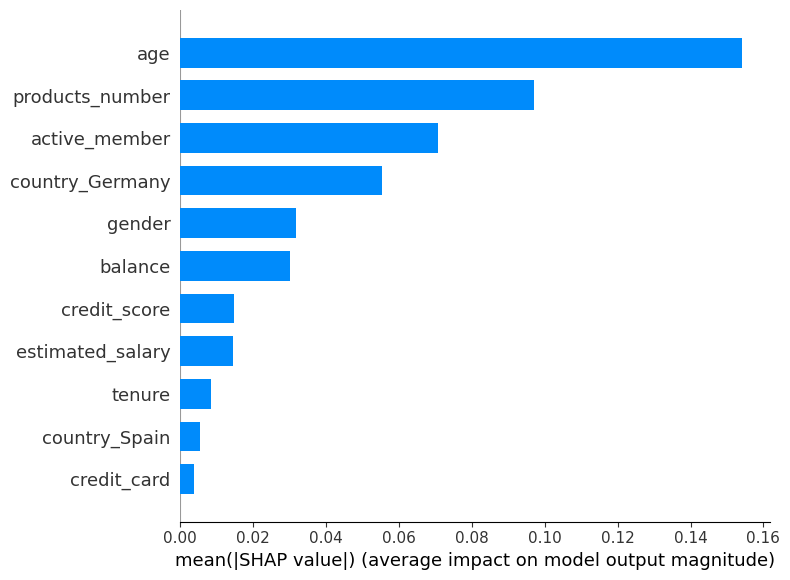

In [302]:
y_probs = RF.predict_proba(X_test)[:, 1]
at_risk_idx = y_probs >= optimal_threshold

shap_class1 = shap_values[:, :, 1]      # SHAP values for class 1 (churn)
X_at_risk   = X_test.iloc[at_risk_idx]
shap_at_risk = shap_class1[at_risk_idx]

# Global feature importance — mean absolute SHAP value
shap.summary_plot(shap_at_risk, X_at_risk, plot_type="bar")

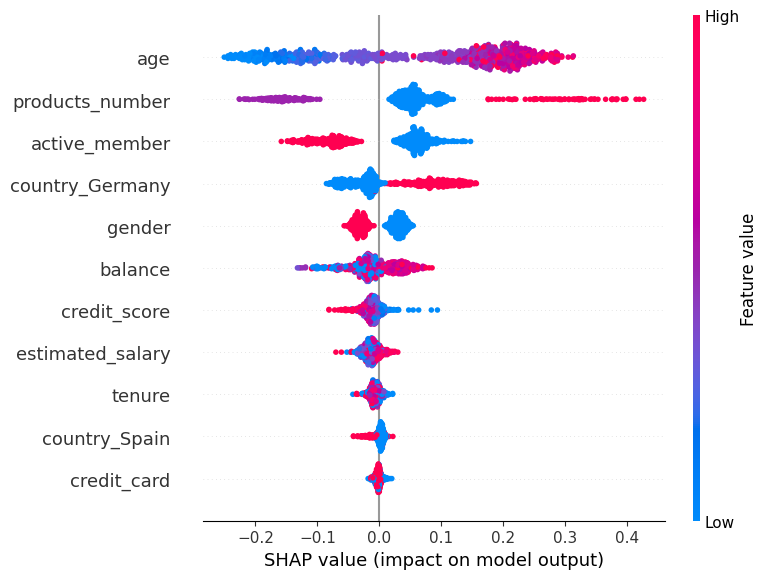

In [304]:
# Detailed dot plot — shows direction and distribution of SHAP values per feature
shap.summary_plot(shap_at_risk, X_at_risk)

The SHAP summary plots confirm the most influential drivers of churn for at-risk customers. Older age, holding 3+ products, and inactive membership are the three dominant factors. The dot plot additionally shows the direction of each feature's effect — e.g. higher age values push the prediction towards churn (positive SHAP), while being an active member pushes it away from churn (negative SHAP).

#### Effect of Age on Churn

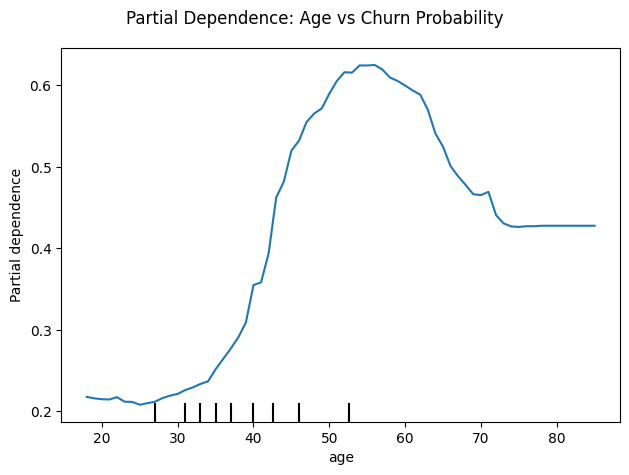

In [306]:
PartialDependenceDisplay.from_estimator(RF, X_test, features=["age"], target=1)
plt.suptitle("Partial Dependence: Age vs Churn Probability")
plt.tight_layout()
plt.show()

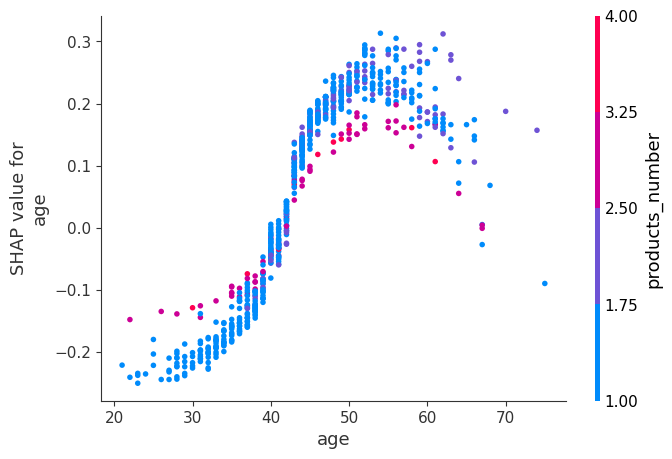

In [308]:
shap.dependence_plot("age", shap_at_risk, X_at_risk, interaction_index='products_number')

The PDP shows that churn probability begins to increase substantially after age 40, peaking in the mid-50s where it reaches over 50% above baseline. The SHAP dependence plot confirms this at the individual level — many customers aged 45–65 have SHAP values between 0.2 and 0.5, meaning age alone is pushing their churn probability substantially higher. The interaction colouring with products_number shows that customers who are both older and hold more products are at compounded risk.

#### Effect of Products Number on Churn

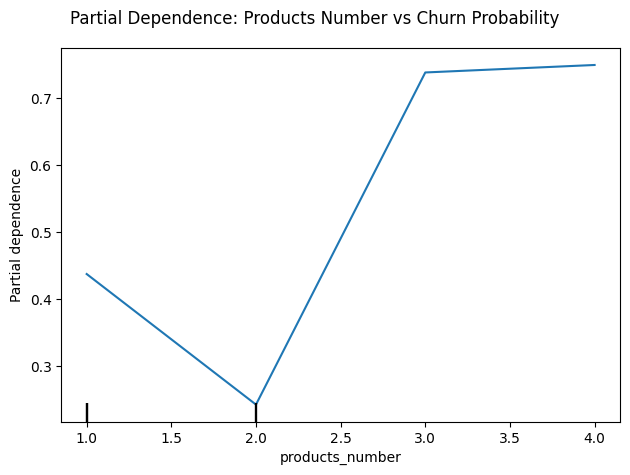

In [310]:
PartialDependenceDisplay.from_estimator(RF, X_test, features=["products_number"], target=1)
plt.suptitle("Partial Dependence: Products Number vs Churn Probability")
plt.tight_layout()
plt.show()

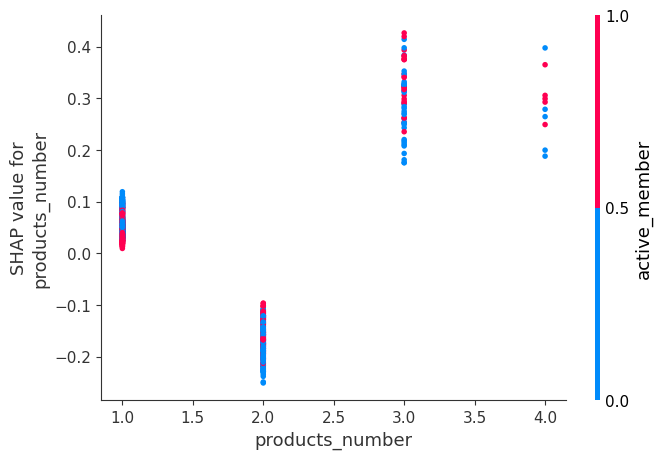

In [141]:
shap.dependence_plot("products_number", shap_at_risk, X_at_risk, interaction_index='active_member')

Customers with 3 or 4 products are at considerably higher churn risk — a non-linear effect that the weak linear correlation coefficient (−0.05) entirely failed to capture. This is likely driven by dissatisfaction with product complexity or bundling, rather than engagement. Notably, this is the opposite of the intuitive expectation that more products = more committed customer.

This reinforces why tree-based models and SHAP are valuable for this dataset: linear measures missed this relationship entirely.

#### Effect of Membership Activity on Churn

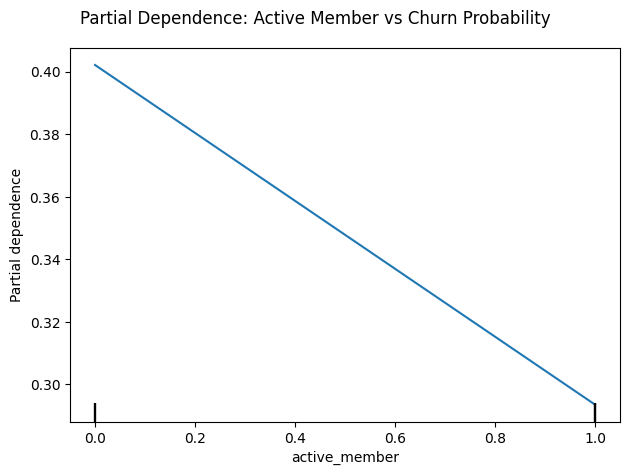

In [316]:
PartialDependenceDisplay.from_estimator(RF, X_test, features=["active_member"], target=1)
plt.suptitle("Partial Dependence: Active Member vs Churn Probability")
plt.tight_layout()
plt.show()

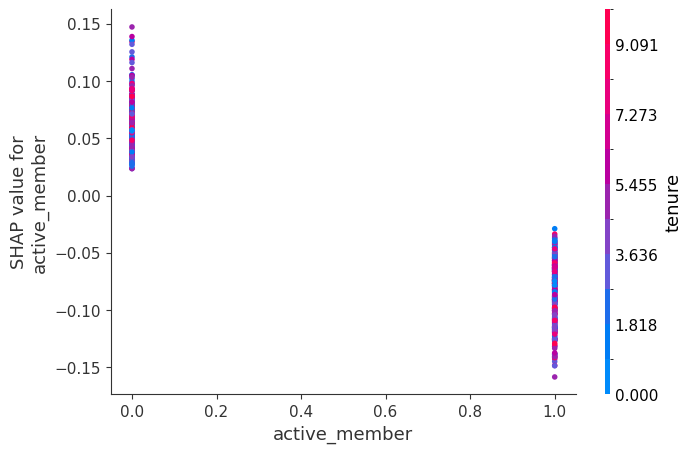

In [314]:
shap.dependence_plot("active_member", shap_at_risk, X_at_risk, interaction_index='tenure')

Non-active members have substantially higher churn probability — the PDP shows a clear step change between active (1) and non-active (0) customers. This suggests that disengagement from the bank is a leading indicator of churn, making `active_member` a potentially useful early warning signal for targeted retention outreach. The magnitude of the effect can be read directly from the PDP plot above.

### Secondary Features

#### Effect of Country on Churn

Note: after one-hot encoding, `country` is represented by two dummy variables — `country_Germany` and `country_Spain` — each interpreted relative to France as the reference category.

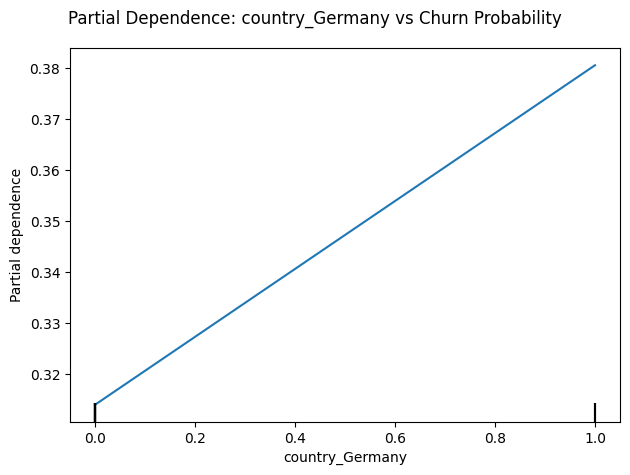

In [318]:
PartialDependenceDisplay.from_estimator(RF, X_test, features=["country_Germany"], target=1)
plt.suptitle("Partial Dependence: country_Germany vs Churn Probability")
plt.tight_layout()
plt.show()

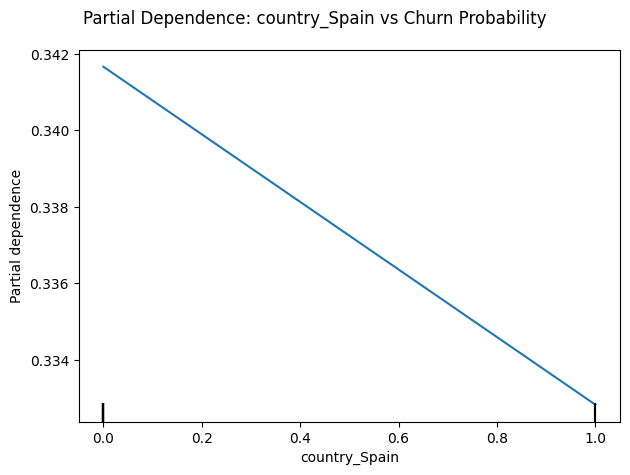

In [320]:
PartialDependenceDisplay.from_estimator(RF, X_test, features=["country_Spain"], target=1)
plt.suptitle("Partial Dependence: country_Spain vs Churn Probability")
plt.tight_layout()
plt.show()

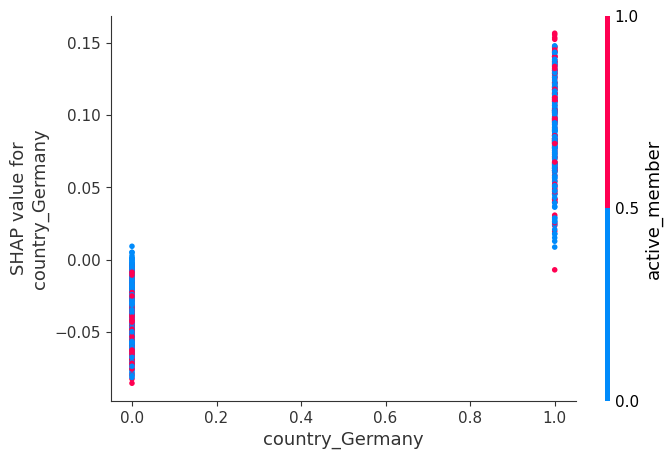

In [322]:
shap.dependence_plot("country_Germany", shap_at_risk, X_at_risk, interaction_index='active_member')

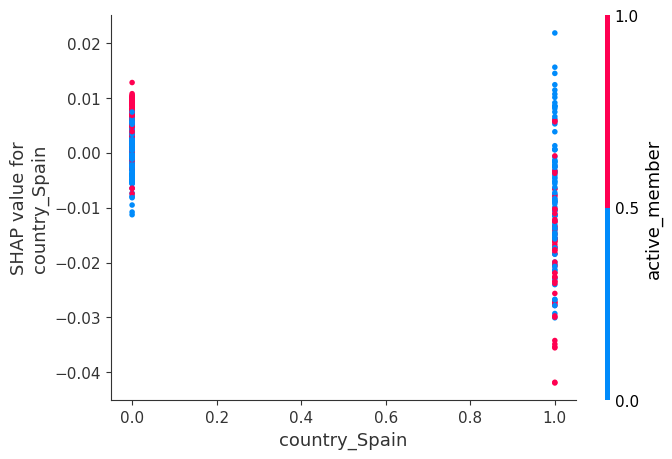

In [324]:
shap.dependence_plot("country_Spain", shap_at_risk, X_at_risk, interaction_index='active_member')

German customers (country_Germany = 1) show a higher churn probability relative to French customers (the reference category). Spanish customers show little difference from French customers, consistent with the low Cramér's V value (0.05) in the heatmap. The interaction with active_member suggests the Germany effect is more pronounced among non-active members.

#### Effect of Balance on Churn

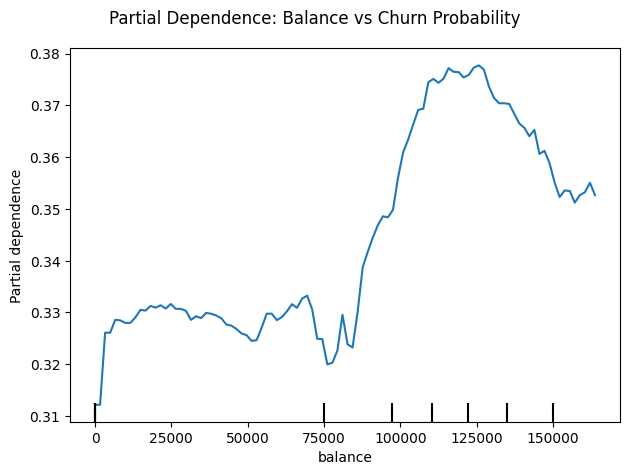

In [326]:
PartialDependenceDisplay.from_estimator(RF, X_test, features=["balance"], target=1)
plt.suptitle("Partial Dependence: Balance vs Churn Probability")
plt.tight_layout()
plt.show()

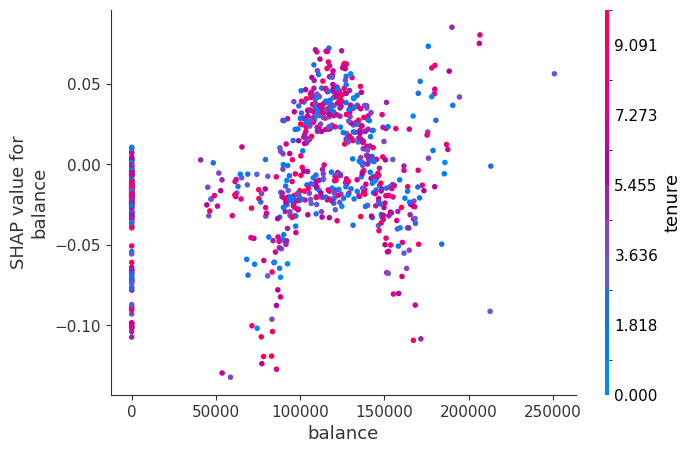

In [330]:
shap.dependence_plot("balance", shap_at_risk, X_at_risk, interaction_index='tenure')

Balance has a modest but non-zero effect on churn, particularly at the upper end of the distribution — customers with very high balances are at elevated risk. The zero-balance spike noted in the EDA means that balance's overall SHAP contribution is muted by the large segment of customers with £0 balance, for whom the feature carries no information.

#### Effect of Gender on Churn

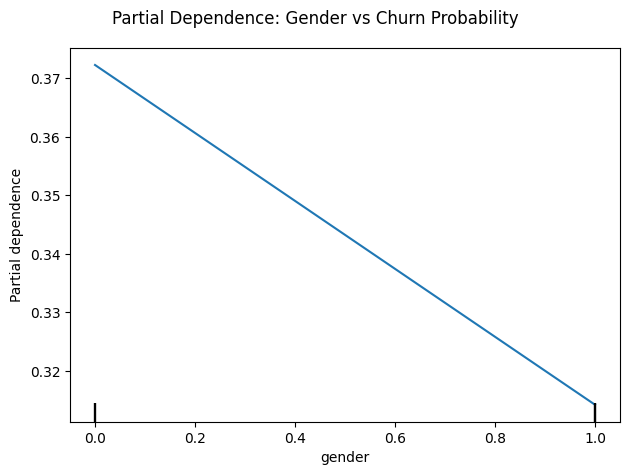

In [334]:
PartialDependenceDisplay.from_estimator(RF, X_test, features=["gender"], target=1)
plt.suptitle("Partial Dependence: Gender vs Churn Probability")
plt.tight_layout()
plt.show()

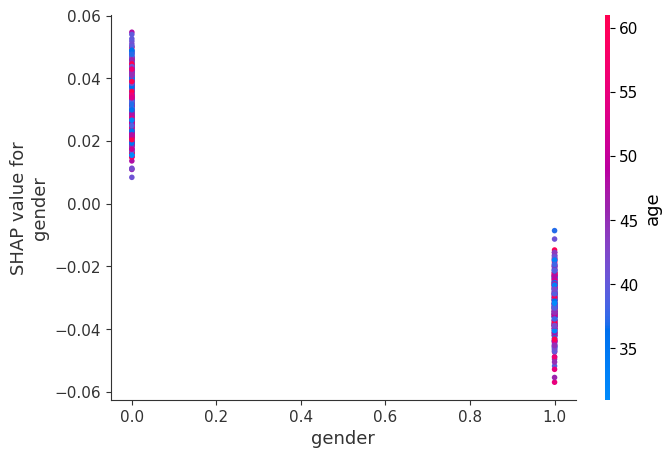

In [336]:
shap.dependence_plot("gender", shap_at_risk, X_at_risk, interaction_index='age')

Female customers (gender = 0) are at modestly higher churn risk than male customers (gender = 1) — consistent with the negative point-biserial coefficient (−0.11) in the heatmap. The effect is secondary relative to age, products, and activity level, but is consistent across the dataset.

**Note on estimated salary and credit score:** Both rank moderately in raw feature importance due to their role in tree splits across a wide continuous range. However, their SHAP contributions are diffuse — there is no clear threshold or direction at the individual level. This discrepancy is a known artefact of how Random Forest measures importance for high-cardinality continuous variables, and SHAP should be given precedence in interpretation.

### Summary

The tuned Random Forest achieves a cross-validated ROC AUC of 0.860, reflecting the improvement from hyperparameter tuning over the baseline (0.853). Evaluated at the F₂-optimal classification threshold, the model achieves high sensitivity (0.831) in identifying customers who churn.

**Feature selection** tested whether removing three statistically insignificant features (credit_card, tenure, estimated_salary) would meaningfully change performance. The cross-validated AUC difference was **0.0098**, exceeding the 0.005 materiality threshold. The full 11-feature model is therefore retained because removing the three features degraded performance beyond the materiality threshold.

**Threshold selection** The F₂-optimal threshold was chosen. It  weights recall twice as heavily as precision to reflect the business cost asymmetry (missed churners cost more than false alarms). The Youden's J threshold is also reported for reference as a symmetric alternative.

**Age** is the most influential predictor of churn. Risk begins to increase meaningfully after age 40, with customers in their late 40s to early 60s at the highest risk. The PDP shows that customers in their mid-50s have substantially higher churn probability than younger customers, holding other features constant.

**Number of products** is the second strongest driver according to SHAP, despite a weak linear correlation (−0.05) — a non-linear effect that only RF modeling captures. Customers with 3 or 4 products are at considerably higher risk.

**Active membership** is a strong protective signal. Non-active members have substantially higher churn probability than active members — the PDP shows a clear step change — suggesting that disengagement is a leading indicator worth monitoring proactively.

**Balance, geography, and gender** are secondary signals. Higher-balance customers are modestly more likely to churn. German customers churn at a higher rate than French or Spanish customers (confirmed by EDA bar charts, Cramér's V = 0.17). Female customers churn at a modestly higher rate than male customers (point-biserial r = −0.11, where Male = 1).

**Estimated salary and credit score** rank highly in raw feature importance due to split frequency across their wide continuous ranges — a known artefact of Random Forest importance for high-cardinality variables. SHAP analysis shows limited directional effect at the individual level. SHAP should be given precedence where the two measures disagree.

#### **Retention priority:** The bank should focus efforts on customers aged 45–65 who hold 3 or more products and show signs of membership disengagement. Customers in Germany, particularly older female customers, represent a high-risk geographic segment warranting targeted intervention. The final model's confusion matrix and threshold comparison table provide the operational inputs needed to size the retention programme.